In [1]:
import pandas as pd
pd.set_option('display.max_Colwidth',None)

In [2]:
df = pd.read_csv('translated_hindi_dataset.csv')

In [3]:
df.head()

,text,Label_binary,translated_text
0,"बांग्लादेश की शानदार वापसी, भारत को 314 रन पर रोका #INDvBAN #CWC19",0,"Great comeback by Bangladesh, restricted India to 314 runs #INDvBAN #CWC19"
1,सब रंडी नाच देखने मे व्यस्त जैसे ही कोई #शांतीदूत के साथ कुछ होगा सब #रंडीरोना शुरू कर देंगे,1,"All the whores are busy watching the dance. As soon as something happens with a #peacemaker, all the #whores will start crying."
2,तुम जैसे हरामियों के लिए बस जूतों की कमी है शुक्र कर अभी तुम्हारी लिंचिंग हुई नहीं है हिंदुओं के जागने की देर है सच में होगी अभी तो तुम जैसे हरामी सुवर ड्रामा बनाएं हो सुवर कहीं का मौलाना। तुम जैसे हरामियों कुत्ते की मौत मारना चाहिए सुवर जैसी शक्ल रंडी की औलाद सुवर कहीं का ।।।।,1,"There is just shortage of shoes for bastards like you. Thank God you have not been lynched yet. It is too late for the Hindus to wake up. It will actually happen now. Bastards like you have created a pig drama, some Maulana of a pig. Bastards like you, the dog should be killed, the pig-like face, the son of a whore, the pig from somewhere."
3,"बीजेपी MLA आकाश विजयवर्गीय जेल से रिहा, जमानत मिलने की खुशी में एक समर्थक ने इंदौर में हर्ष फायरिंग की #AkashVijayvargiya https://abpnews.abplive.in/india-news/celebratory-firing-outside-bjp-mla-akash-vijayvargiya-office-in-indore-1157241 …",0,"BJP MLA Akash Vijayvargiya released from jail, in celebration of getting bail, a supporter opened fire in Indore #AkashVijayvargiya https://abpnews.abplive.in/india-news/celebratory-firing-outside-bjp-mla-akash-vijayvargiya-office-in-indore-1157241…"
4,"चमकी बुखार: विधानसभा परिसर में आरजेडी का प्रदर्शन, तेजस्वी यादव नदारद #biharencephalitisdeaths https://abpnews.abplive.in/bihar-news/aes-deaths-rjd-protest-in-vidhan-sabha-campus-but-tejashwi-yadav-was-not-present-1158748 … (रिपोर्ट- @kumarprakash4u )",0,"Chamki fever: RJD's protest in the assembly campus, Tejashwi Yadav missing #biharencephalitisdeaths https://abpnews.abplive.in/bihar-news/aes-deaths-rjd-protest-in-vidhan-sabha-campus-but-tejashwi-yadav-was-not-present-1158748… (Report- @kumarprakash4u)"


In [4]:
# Cleanup / preprocessing
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4665 entries, 0 to 4664
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   text             4665 non-null   object
 1   Label_binary     4665 non-null   int64 
 2   translated_text  4655 non-null   object
dtypes: int64(1), object(2)
memory usage: 109.5+ KB


In [5]:
df.isnull().sum()

text                0
Label_binary        0
translated_text    10
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df = df.dropna(subset = 'translated_text')

In [8]:
df.isnull().sum()

text               0
Label_binary       0
translated_text    0
dtype: int64

In [9]:
df['Label_binary'].value_counts()

Label_binary
1    2465
0    2190
Name: count, dtype: int64

In [10]:
 "Unnamed : 0" in df.columns

False

In [11]:
df['text_length'] = df['translated_text'].astype(str).apply(len)
df['text_length'].describe()

count    4655.000000
mean      168.645542
std        91.939942
min         6.000000
25%        93.000000
50%       151.000000
75%       238.000000
max       719.000000
Name: text_length, dtype: float64

In [12]:
# explain here the .describe() analysis
df

,text,Label_binary,translated_text,text_length
0,"बांग्लादेश की शानदार वापसी, भारत को 314 रन पर रोका #INDvBAN #CWC19",0,"Great comeback by Bangladesh, restricted India to 314 runs #INDvBAN #CWC19",74
1,सब रंडी नाच देखने मे व्यस्त जैसे ही कोई #शांतीदूत के साथ कुछ होगा सब #रंडीरोना शुरू कर देंगे,1,"All the whores are busy watching the dance. As soon as something happens with a #peacemaker, all the #whores will start crying.",127
2,तुम जैसे हरामियों के लिए बस जूतों की कमी है शुक्र कर अभी तुम्हारी लिंचिंग हुई नहीं है हिंदुओं के जागने की देर है सच में होगी अभी तो तुम जैसे हरामी सुवर ड्रामा बनाएं हो सुवर कहीं का मौलाना। तुम जैसे हरामियों कुत्ते की मौत मारना चाहिए सुवर जैसी शक्ल रंडी की औलाद सुवर कहीं का ।।।।,1,"There is just shortage of shoes for bastards like you. Thank God you have not been lynched yet. It is too late for the Hindus to wake up. It will actually happen now. Bastards like you have created a pig drama, some Maulana of a pig. Bastards like you, the dog should be killed, the pig-like face, the son of a whore, the pig from somewhere.",343
3,"बीजेपी MLA आकाश विजयवर्गीय जेल से रिहा, जमानत मिलने की खुशी में एक समर्थक ने इंदौर में हर्ष फायरिंग की #AkashVijayvargiya https://abpnews.abplive.in/india-news/celebratory-firing-outside-bjp-mla-akash-vijayvargiya-office-in-indore-1157241 …",0,"BJP MLA Akash Vijayvargiya released from jail, in celebration of getting bail, a supporter opened fire in Indore #AkashVijayvargiya https://abpnews.abplive.in/india-news/celebratory-firing-outside-bjp-mla-akash-vijayvargiya-office-in-indore-1157241…",249
4,"चमकी बुखार: विधानसभा परिसर में आरजेडी का प्रदर्शन, तेजस्वी यादव नदारद #biharencephalitisdeaths https://abpnews.abplive.in/bihar-news/aes-deaths-rjd-protest-in-vidhan-sabha-campus-but-tejashwi-yadav-was-not-present-1158748 … (रिपोर्ट- @kumarprakash4u )",0,"Chamki fever: RJD's protest in the assembly campus, Tejashwi Yadav missing #biharencephalitisdeaths https://abpnews.abplive.in/bihar-news/aes-deaths-rjd-protest-in-vidhan-sabha-campus-but-tejashwi-yadav-was-not-present-1158748… (Report- @kumarprakash4u)",253
...,...,...,...,...
4660,पाकिस्तान ने हिंदुओं के ख़िलाफ़ बोलने वाले को बर्खास्त किया है । क्या भारत में भी मुसलमानों के ख़िलाफ़ ज़हर उगलने वालों को मोदी जी करेंगे बर्खास्त ? ⁦@narendramodi⁩ ⁦@BJP4India⁩ ⁦@RSSorg⁩ ⁦@INCIndia⁩,0,Pakistan has dismissed the person who spoke against Hindus. Will Modi ji fire those who spew venom against Muslims in India too? @narendramodi @BJP4India @RSSorg @INCIndia,171
4661,कोहली है #नेहरू नहीं जो अंग्रेजों के तलवे चाटने लगे । भड़वा साला #जवाहर,1,"It is Kohli, not #Nehru, who started licking the soles of the British. You bastard #Jawahar",91
4662,परशुराम? वही जिसने अपनी मां की हत्या की थीं?,0,Parshuram? The same one who killed his mother?,46
4663,जिस देश में #कन्हैया_कुमार जैसा पढ़ा लिखा युवा हार जाए #आतंकवादी जीत जाये उस देश की जनता क्या ?,1,What about the people of a country where an educated youth like #Kanhaiya_Kumar loses and a #terrorist wins?,108


## Lowercasing

In [13]:
df['translated_text'] = df['translated_text'].str.lower()

Here we will check about the presence of tags or url in the dataset

In [14]:
df[df['translated_text'].str.contains(r'https?://\S+|www\.\S+|@\w+|#\w+|<[^>]+>', na = False)].shape


(2027, 4)

In [15]:
df['clean_text'] = df['translated_text'].str.replace(r'https?://\S+|www\.\S+|@\w+', '', regex=True)
df['clean_text'] = df['clean_text'].str.replace(r'#', '', regex=True)


In [16]:
df.sample(100 , random_state = 42)

,text,Label_binary,translated_text,text_length,clean_text
1618,बिहार में चमकी बुखार के प्रकोप पर सीएम नीतीश कुमार LIVE देखने के लिए नीचे लिंक पर क्लिक करें: https://www.youtube.com/watch?v=ufqXGYKZEY8 …,0,click on the link below to watch cm nitish kumar live on the outbreak of chamki fever in bihar: https://www.youtube.com/watch?v=ufqxgykzey8…,140,click on the link below to watch cm nitish kumar live on the outbreak of chamki fever in bihar:
1184,Phla kadam hi lad khadata hua nazar aara hai....seat hi bchaalo phle apni,0,"at every step, i look at what i have eaten....save your seat.",61,"at every step, i look at what i have eaten....save your seat."
2183,निशांत वर्मा वेश्यावृत्ति की उपज है या गटर के सुअर का औलाद।।,1,is nishant verma the product of prostitution or the offspring of a gutter pig?,78,is nishant verma the product of prostitution or the offspring of a gutter pig?
3534,"क्यों सुअर , कभी तू भी काफिर ही था , वो तो औरंजेब ने लूटी अस्मत 5/7 पीढी पहले , डर के तेरे बाबा , पड़ बाबे मुल्ला बन बैठे , अम्मी से पूछ वो सारा सच बताएगी",1,"why pig, once upon a time you were also an infidel, it was auranzeb who looted the honor 5/7 generations ago, out of fear your father became a mullah, ask your mother, she will tell you the whole truth.",202,"why pig, once upon a time you were also an infidel, it was auranzeb who looted the honor 5/7 generations ago, out of fear your father became a mullah, ask your mother, she will tell you the whole truth."
634,"दंगाई मस्त, पुलिस पस्त! देखिए #Dangal @sardanarohit के साथ, शाम 5 बजे, सिर्फ आजतक पर",0,"rioters are happy, police are defeated! watch #dangal with @sardanarohit at 5 pm only on aaj tak",97,"rioters are happy, police are defeated! watch dangal with at 5 pm only on aaj tak"
...,...,...,...,...,...
3163,जब पेल देता है तो तुम सब सुअरो की तरह चिल्लाने लगते। अभी तबरेज का ही देख लो। चोर को पेला तो हर तरफ रंडी रोना चालू।,1,"when the pail is given, you all start screaming like pigs. now just look at tabrez. when the thief was beaten, the whores everywhere started crying.",148,"when the pail is given, you all start screaming like pigs. now just look at tabrez. when the thief was beaten, the whores everywhere started crying."
3842,#कुत्ते दो तरीके के पाले जाते हैं एक पाला हुआ दूसरा खरीदा हुआ मणिशंकर कांग्रेस का पाला हुआ कुत्ता है और सिद्धू खरीदा हुआ,1,"#dogs are reared in two ways, one is reared and the other is bought. mani shankar is a reared dog of congress and sidhu is a purchased one.",139,"dogs are reared in two ways, one is reared and the other is bought. mani shankar is a reared dog of congress and sidhu is a purchased one."
2389,"हर जगह बच्चों की मौत का मातम है लेकिन कुछ चंद पत्रकार अपनी भक्ति का परिचय देते हुए पक्ष विपक्ष का खेल खेल रहे। शर्म आनी चाहिए ऐसे चरनचुम्बी चरणचट्टू पत्रकारो को काश पत्रकार बिके ना होते , तो शायद अंधी सरकार की आंखे मासूम बच्चो की तरफ आ जाती? खैर हिन्दू-मुस्लिम सलामत रहे।",0,"everywhere there is mourning over the death of children but a few journalists are showing their devotion and playing the game of side and opposition. such journalists should be ashamed. i wish journalists had not been sold, then perhaps the eyes of the blind government would have turned towards the innocent children. well hindus and muslims remain safe.",361,"everywhere there is mourning over the death of children but a few journalists are showing their devotion and playing the game of side and opposition. such journalists should be ashamed. i wish journalists had not been sold, then perhaps the eyes of the blind government would have turned towards the innocent children. well hindus and muslims remain safe."
316,जिससे मेरा दिल ना मिले मेरे बस का नहीं है उससे नज़र मिलाना उसके साथ रहना और उससे बात करना तो बहुत दूर की बात है,0,it is not in my power to make eye contact with someone who does not share my heart; it is a very distant thing to be with him and talk to him.,142,it is not in my power to make eye contact with someone who does not share my heart; it is a very distant thing to be with h

In [17]:
# Puntuation handeling 

import string

print(string.punctuation)
exclude = string.punctuation

def punctuation_remove(text):
    return text.translate(str.maketrans('','',exclude))

df['clean_text'] = df['clean_text'].apply(punctuation_remove)

!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~


In [18]:
# There were some hindi words in it so i have replaced those with spaces 

df['clean_text'] = df['clean_text'].str.replace(r'[^a-zA-Z\s]', ' ', regex=True)

In [19]:
# def clean(text):
#     text = text.lower()
    
#     text = text.replace(r'https?://\S+|www\.\S+|@\w+', '', regex=True)
#     text = text.replace(r'#', '', regex=True)
#     exclude = string.punctuation

#     def punctuation_remove(text):
#         return text.translate(str.maketrans('','',exclude))

#     text = punctuation_remove(text)
#     text = text.replace(r'[^a-zA-Z\s]', ' ', text , regex = True)

#     def remove_stopwords(text):
#         return " ".join([word for word in text.split() if word  not in stopwords])

#     text = remove_stopwords(text)

#     def lemmatize_text(text):
#         return " ".join([lemmatizer.lemmatize(word) for word in text.split()])

#     text = lemmatize_text(text)
#     return text
                                              

## Check for Emojis

In [20]:
df[df["clean_text"].str.contains(r"[\U00010000-\U0010ffff]" , na = False)].shape
# No emoji is found

(0, 5)

## Stop Words

In [21]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

stopwords = set(ENGLISH_STOP_WORDS)
stopwords.discard('no')
stopwords.discard('not')
stopwords.discard('never')
stopwords.discard('nor')

def remove_stopwords(text):
    return " ".join([word for word in text.split() if word  not in stopwords])

df['clean_text'] = df['clean_text'].apply(remove_stopwords)

## Lemmatizer

In [22]:
from nltk.stem import WordNetLemmatizer
import nltk
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [23]:
lemmatizer = WordNetLemmatizer()

def lemmatize_text(text):
    return " ".join([lemmatizer.lemmatize(word) for word in text.split()])

df["Content_lemma"] = df["clean_text"].apply(lemmatize_text)

df.sample(10,random_state = 42)

In [24]:
def clean(text):
    import re
    # Lowercase
    text = text.lower()

    # Remove URLs and mentions
    text = re.sub(
        r'https?://\S+|www\.\S+|@\w+',
        '',
        text
    )

    # Remove # symbol
    text = re.sub(r'#', '', text)

    # Remove punctuation
    exclude = string.punctuation
    text = text.translate(
        str.maketrans('', '', exclude)
    )

    # Keep only English letters and whitespace
    text = re.sub(
        r'[^a-zA-Z\s]',
        ' ',
        text
    )

    # Remove stopwords
    text = " ".join(
        word for word in text.split()
        if word not in stopwords
    )

    # Lemmatization
    text = " ".join(
        lemmatizer.lemmatize(word)
        for word in text.split()
    )

    return text

## Model Trianing begin........

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report , confusion_matrix,accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [26]:
# splitting of the data
x = df['Content_lemma']
# x = df['Content_lemma']
y = df['Label_binary']
x_train,x_test,y_train,y_test = train_test_split(
    x,y ,test_size = 0.2 , random_state = 42
)

In [27]:
# vectorisation by  Tf-idf with n-gram

tfidf = TfidfVectorizer(
    ngram_range = (1,3),
    max_features = 15000,
    min_df = 3,
    max_df = 0.85
)

x_train_tfidf = tfidf.fit_transform(x_train)
x_test_tfidf = tfidf.transform(x_test)

In [28]:
model = LogisticRegression(
    max_iter = 1000,
    class_weight='balanced')
 
model.fit(x_train_tfidf , y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [29]:
y_pred = model.predict(x_test_tfidf)
lr_acc = accuracy_score(y_test,y_pred)
print(f'Accuracy : {lr_acc:.4f}({lr_acc*100:.2f})')
print("Classification report for logistic regression is :\n",classification_report(y_test , y_pred))

Accuracy : 0.8013(80.13)
Classification report for logistic regression is :
               precision    recall  f1-score   support

           0       0.77      0.82      0.79       437
           1       0.83      0.79      0.81       494

    accuracy                           0.80       931
   macro avg       0.80      0.80      0.80       931
weighted avg       0.80      0.80      0.80       931



In [30]:
# INPUT PIPELINE

from deep_translator import GoogleTranslator
translator = GoogleTranslator(source = 'auto', target = 'en')
test_statements = [
    "कुत्ते की तरह भौंकना बंद कर, तेरी कोई औकात नहीं है।",
    "इस गद्दार को देश से निकाल देना चाहिए, यह देशद्रोही है।",
    "तुम ल��ग एकदम गवार और जाहिल हो, तुमको अकल नहीं है।",
    "शर्म कर बे, तुम जैसों को तो चौराहे पर पीटना चाहिए।",
    "बकवास बंद कर बेवकूफ, तेरा दिमाग सड़ गया है।",
    "तुम जैसे बेवकूफों को तो जेल में डाल देना चाहिए।",
    "आज मौसम बहुत अच्छा है, चलो कहीं घूमने चलते हैं।",
    "तू एक नंबर का झूठा और नीच इंसान है।",
    "भाई, क्या तुम मुझे कल की मीटिंग का समय बता सकते हो?",
    "मैं किसी से नफरत नहीं करता, सब मेरे दोस्त हैं।",
    "इन गद्दारों को देश से मार भगाओ।",
    "तुम बहुत काले हो"
]
test_state = []
for text in test_statements:
    english = translator.translate(text)
    test_state.append(english)
inputs = tfidf.transform(test_state)
model.predict(inputs)

array([0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0])

In [31]:
from sklearn.svm import LinearSVC as svm1
from sklearn.calibration import CalibratedClassifierCV

In [32]:
svm = svm1(
    C=1.0,
    max_iter = 2000,
    class_weight = 'balanced'
)
svm_model = CalibratedClassifierCV(svm)
svm_model.fit(x_train_tfidf , y_train)
print('SVM training done!')

SVM training done!


In [33]:
# predict

y_pred_svm = svm_model.predict(x_test_tfidf)
y_prob_svm = svm_model.predict_proba(x_test_tfidf)
print(y_prob_svm)
print(y_pred_svm)
svm_acc = accuracy_score(y_test,y_pred_svm)
print(f'Accuracy: {svm_acc:.4f}({svm_acc*100:.2f}%)')
print()
print(classification_report(
    y_test , y_pred_svm , target_names=['Not Hate(0)' , 'Hate Speech(1)']
))
svm_acc*100

[[0.94575027 0.05424973]
 [0.68625543 0.31374457]
 [0.10475577 0.89524423]
 ...
 [0.00468148 0.99531852]
 [0.7775261  0.2224739 ]
 [0.68193404 0.31806596]]
[0 0 1 1 0 0 0 1 0 1 0 0 0 0 0 1 1 1 0 0 1 0 1 0 0 1 1 0 1 0 1 1 1 0 0 0 1
 0 0 0 1 0 0 0 1 0 0 1 0 1 1 1 0 1 0 1 0 0 1 1 0 0 0 0 1 0 0 1 0 1 1 1 1 1
 1 0 0 1 1 1 1 1 1 0 0 1 1 1 1 0 0 1 0 0 0 1 1 0 0 0 0 1 0 1 1 1 0 0 0 1 1
 0 1 0 0 1 1 1 1 1 0 1 1 0 1 1 1 0 1 0 1 1 0 1 0 1 1 1 1 1 0 0 0 1 1 0 0 0
 1 1 1 1 1 1 1 0 0 1 1 1 0 0 0 1 0 1 0 0 1 1 0 1 1 1 0 1 0 0 0 0 0 1 1 1 1
 1 1 0 0 0 1 0 1 1 1 1 1 0 1 0 1 1 1 1 1 0 1 1 1 1 0 0 0 1 0 0 0 0 1 0 0 0
 0 1 0 1 0 0 0 0 0 0 0 0 0 1 1 0 0 1 1 0 0 0 1 1 1 1 0 0 1 1 0 1 1 1 1 0 0
 1 1 1 0 1 0 0 1 0 1 0 1 0 1 1 1 0 0 0 0 1 0 1 0 1 0 1 0 1 0 0 0 1 0 0 1 0
 1 1 1 0 0 0 0 0 1 1 0 1 0 0 1 1 0 1 0 1 0 1 0 0 1 1 1 0 1 1 0 0 0 1 0 1 1
 0 1 0 0 1 0 0 0 1 1 1 0 0 1 1 1 1 1 0 1 1 0 1 1 0 1 1 0 0 0 1 0 1 0 0 1 1
 0 0 0 1 0 0 0 1 0 1 0 0 1 1 1 1 1 1 1 0 1 0 1 1 1 0 1 0 1 0 1 1 0 1 0 1 1
 0 1 1 0 1 0 1 1 1 

80.02148227712136

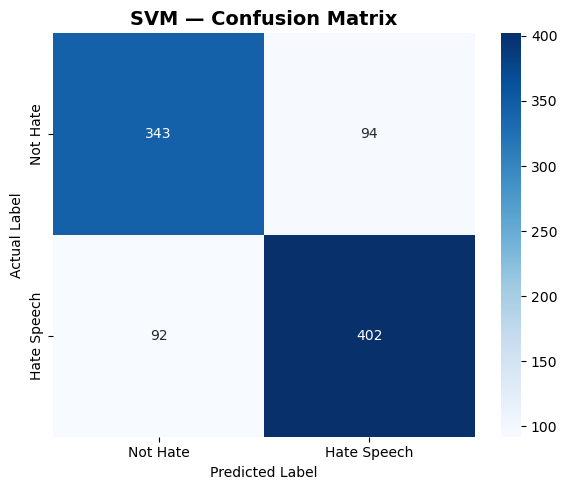

In [34]:
cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_svm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not Hate', 'Hate Speech'],
    yticklabels=['Not Hate', 'Hate Speech']
)
plt.title('SVM — Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('svm_confusion_matrix.png', dpi=150)
plt.show()

# Top-left     = True Negatives  (correctly predicted NOT hate)
# Top-right    = False Positives (predicted hate, actually not hate)
# Bottom-left  = False Negatives (predicted not hate, actually hate) ← worst error
# Bottom-right = True Positives  (correctly predicted hate)

In [35]:
print(accuracy_score(y_test,y_pred_svm)*100)

80.02148227712136


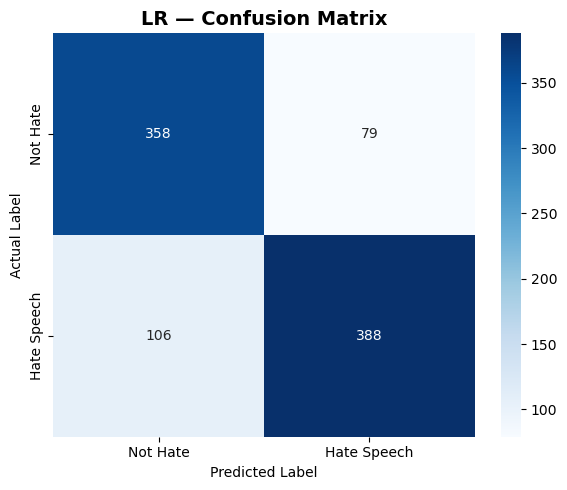

In [36]:
cm_LR = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_LR,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not Hate', 'Hate Speech'],
    yticklabels=['Not Hate', 'Hate Speech']
)
plt.title('LR — Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('svm_confusion_matrix.png', dpi=150)
plt.show()

In [37]:
from sklearn.preprocessing import FunctionTransformer

def clean_series(texts):
    return texts.apply(clean)

clean_transformer = FunctionTransformer(clean_series)

In [38]:
x_fresh = df['translated_text']
y_fresh = df['Label_binary']

x_train_fresh , x_test_fresh , y_train_fresh , y_test_fresh = train_test_split(
    x_fresh,
    y_fresh,
    random_state=42,
    test_size=0.2
)

In [39]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer

pipeline = Pipeline([('clean' , clean_transformer),
                ('tfidf' , TfidfVectorizer(
                        ngram_range = (1,3),
                        max_features = 15000,
                        min_df = 3,
                        max_df = 0.85
                )),
                ('svm' ,svm1(
                        C=1.0,
                        max_iter = 2000,
                        class_weight = 'balanced'
                        )),
                # ('svm_model' ,CalibratedClassifierCV(svm))

                ])

In [40]:
pipeline.fit(x_train_fresh,y_train_fresh)
y_pipeline = pipeline.predict(x_test_fresh)
print(accuracy_score(y_test_fresh,y_pipeline))


0.7959183673469388


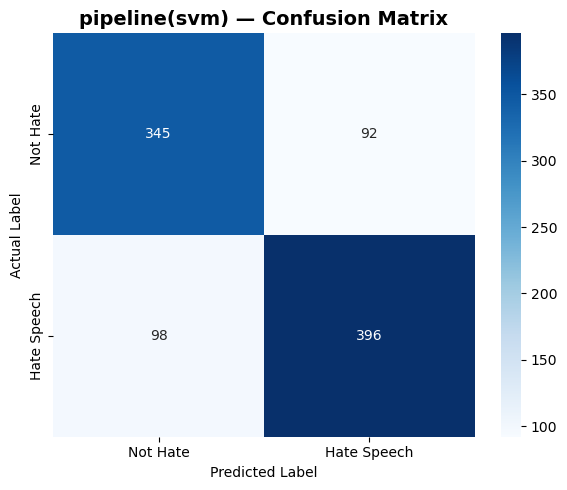

In [41]:
cm_pipe = confusion_matrix(y_test_fresh, y_pipeline)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_pipe,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not Hate', 'Hate Speech'],
    yticklabels=['Not Hate', 'Hate Speech']
)
plt.title('pipeline(svm) — Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('svm_confusion_matrix.png', dpi=150)
plt.show()

In [42]:
pipeline2 = Pipeline([('clean' , clean_transformer),
                ('tfidf' , TfidfVectorizer(
                        ngram_range = (1,3),
                        max_features = 15000,
                        min_df = 3,
                        max_df = 0.85
                )),
                ('lr' , LogisticRegression(
                    max_iter=1000,
                    # class_weight='balanced'
                )),

                ])

In [43]:
pipeline2.fit(x_train_fresh,y_train_fresh)
y_pipeline2 = pipeline2.predict(x_test_fresh)
print(accuracy_score(y_test_fresh,y_pipeline2))

0.7980665950590763


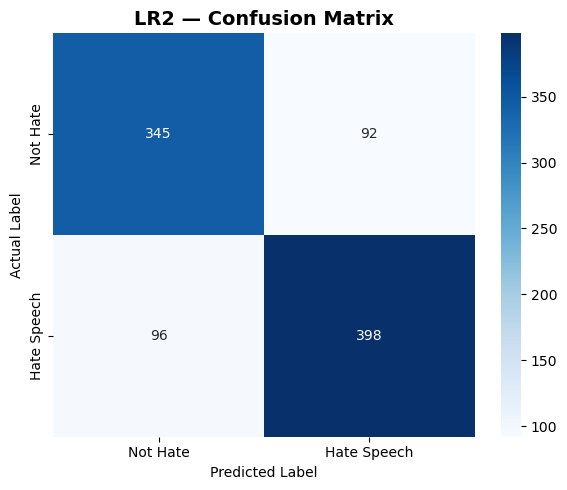

In [44]:
cm_LR2 = confusion_matrix(y_test_fresh, y_pipeline2)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_LR2,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not Hate', 'Hate Speech'],
    yticklabels=['Not Hate', 'Hate Speech']
)
plt.title('LR2 — Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('svm_confusion_matrix.png', dpi=150)
plt.show()

In [48]:
import pickle

with open('Hate_speech_pipeline2.pkl' , 'wb') as f:
    pickle.dump(pipeline2,f)
    print('Final model is saved successfully')
with open('Hate_speech_pipeline.pkl' , 'rb') as f:
    loaded = pickle.load(f)

type(loaded)

Final model is saved successfully


sklearn.pipeline.Pipeline

In [46]:
loaded.predict(x_test_fresh.head())

array([0, 0, 1, 1, 0])

In [47]:
x_test_fresh.head()

1618                                                                  click on the link below to watch cm nitish kumar live on the outbreak of chamki fever in bihar: https://www.youtube.com/watch?v=ufqxgykzey8…
1184                                                                                                                                                 at every step, i look at what i have eaten....save your seat.
2183                                                                                                                                is nishant verma the product of prostitution or the offspring of a gutter pig?
3534    why pig, once upon a time you were also an infidel, it was auranzeb who looted the honor 5/7 generations ago, out of fear your father became a mullah, ask your mother, she will tell you the whole truth.
634                                                                                                              rioters are happy, police are defeated!  wa